# SMS Spam Detection — Support Vector Machine (SVM)
**Mata Kuliah**: Dasar Ilmu Data II  
**Metode**: Support Vector Machine (SVM) + TF-IDF  
**Dataset**: SMS Spam Collection (UCI ML Repository)

---
### 📋 Alur Kerja
1. Import Library
2. Load & Eksplorasi Data
3. Preprocessing Teks
4. Ekstraksi Fitur (TF-IDF)
5. Split Data
6. Training Model SVM
7. Hyperparameter Tuning (Grid Search)
8. Evaluasi Model
9. Prediksi Manual


## 1. Import Library

In [ ]:
# Install library yang dibutuhkan
!pip install nltk scikit-learn imbalanced-learn pandas matplotlib seaborn -q
print("✅ Library berhasil diinstall!")

✅ Library berhasil diinstall!


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil terhubung!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil terhubung!


In [ ]:
# Library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP & Preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model & Evaluasi
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)

# Oversampling
from imblearn.over_sampling import SMOTE

# Download resource NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


## 2. Load & Eksplorasi Data

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('spam.csv', encoding='latin-1')

Saving spam.csv to spam (2).csv


In [ ]:
# Load dataset dari Google Drive
# Pastikan spam.csv sudah diupload ke Google Drive (MyDrive)
# Jika spam.csv ada di dalam folder, sesuaikan path-nya
# Contoh: /content/drive/MyDrive/NamaFolder/spam.csv

df = pd.read_csv('/content/drive/MyDrive/spam.csv', encoding='latin-1')

# Ambil hanya kolom yang relevan dan rename
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

print("Shape dataset:", df.shape)
print("\nSampel data:")
display(df.head(10))

Shape dataset: (5572, 2)

Sampel data:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [ ]:
# Cek nilai kosong
print("Nilai kosong per kolom:")
print(df.isnull().sum())

print("\nDistribusi label:")
print(df['label'].value_counts())
print(f"\nPersentase spam: {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")
print(f"Persentase ham : {df['label'].value_counts(normalize=True)['ham']*100:.1f}%")


Nilai kosong per kolom:
label    0
text     0
dtype: int64

Distribusi label:
label
ham     4825
spam     747
Name: count, dtype: int64

Persentase spam: 13.4%
Persentase ham : 86.6%


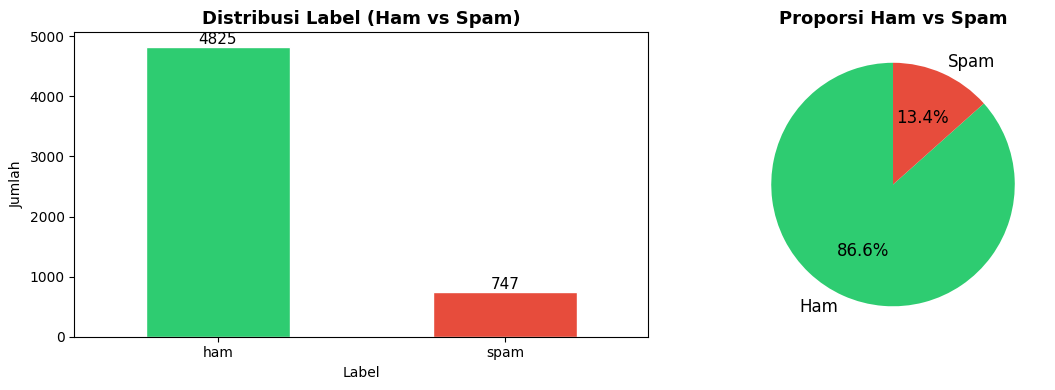

✅ Visualisasi distribusi label selesai.


In [ ]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Distribusi Label (Ham vs Spam)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(df['label'].value_counts(),
            labels=['Ham', 'Spam'],
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Ham vs Spam', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi distribusi label selesai.")


Statistik panjang karakter per label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.02,58.02,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.87,29.18,13.0,132.5,149.0,157.0,224.0



Statistik jumlah kata per label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,14.20,11.42,1.0,7.0,11.0,19.0,171.0
spam,747.0,23.85,5.81,2.0,22.0,25.0,28.0,35.0


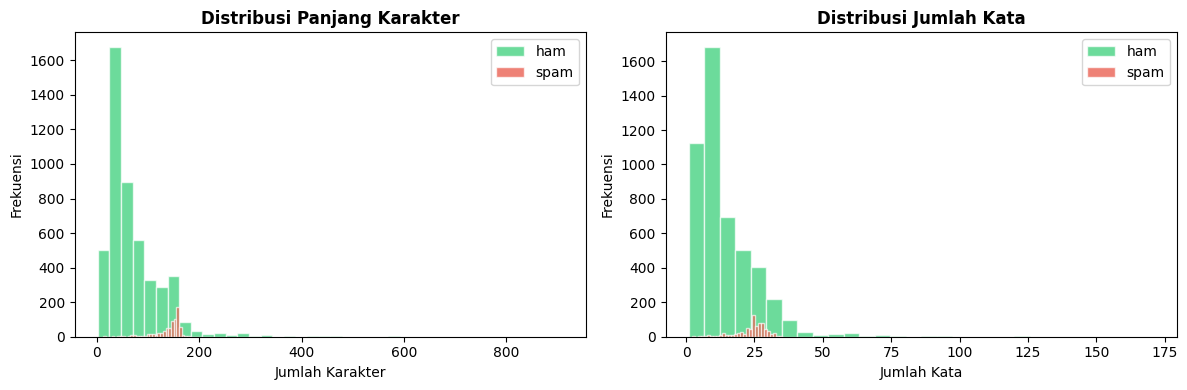

In [ ]:
# Analisis panjang teks
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Statistik panjang karakter per label:")
display(df.groupby('label')['text_length'].describe().round(2))

print("\nStatistik jumlah kata per label:")
display(df.groupby('label')['word_count'].describe().round(2))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in zip(['ham', 'spam'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]
    axes[0].hist(subset['text_length'], bins=40, alpha=0.7, label=label, color=color, edgecolor='white')
    axes[1].hist(subset['word_count'], bins=30, alpha=0.7, label=label, color=color, edgecolor='white')

axes[0].set_title('Distribusi Panjang Karakter', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

axes[1].set_title('Distribusi Jumlah Kata', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Preprocessing Teks

Tahapan preprocessing yang dilakukan:
1. **Lowercase** — ubah semua teks menjadi huruf kecil
2. **Remove URL** — hapus link/URL
3. **Remove angka & tanda baca** — bersihkan karakter non-alfabet
4. **Tokenisasi** — pecah kalimat menjadi kata
5. **Stopword removal** — hapus kata umum yang tidak bermakna (the, is, at, ...)
6. **Stemming** — ubah kata ke bentuk dasarnya (running → run)


In [ ]:
# Inisialisasi tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    """
    Fungsi preprocessing teks lengkap untuk SMS Spam Detection.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Hapus angka
    text = re.sub(r'\d+', '', text)

    # 4. Hapus tanda baca dan karakter spesial
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Tokenisasi
    tokens = text.split()

    # 7. Stopword removal + Stemming
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Terapkan preprocessing
df['text_clean'] = df['text'].apply(preprocess_text)

# Tampilkan perbandingan sebelum & sesudah
print("Perbandingan teks sebelum dan sesudah preprocessing:")
print("=" * 70)
for i in [0, 2, 5]:
    print(f"\n[Baris {i}] Label: {df['label'][i].upper()}")
    print(f"SEBELUM : {df['text'][i]}")
    print(f"SESUDAH : {df['text_clean'][i]}")

print("\n✅ Preprocessing selesai!")


Perbandingan teks sebelum dan sesudah preprocessing:

[Baris 0] Label: HAM
SEBELUM : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
SESUDAH : go jurong point crazi avail bugi n great world la e buffet cine got amor wat

[Baris 2] Label: SPAM
SEBELUM : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
SESUDAH : free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over

[Baris 5] Label: SPAM
SEBELUM : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
SESUDAH : freemsg hey darl week word back id like fun still tb ok xxx std chg send å£ rcv

✅ Preprocessing selesai!


## 4. Ekstraksi Fitur — TF-IDF

**TF-IDF (Term Frequency-Inverse Document Frequency)** mengubah teks menjadi vektor angka.

- **TF (Term Frequency)**: seberapa sering kata muncul dalam satu dokumen
- **IDF (Inverse Document Frequency)**: seberapa langka kata tersebut di seluruh dokumen — kata yang sangat umum (muncul di semua dokumen) diberi bobot kecil
- **TF-IDF** = TF × IDF → kata yang sering di satu dokumen tapi jarang di dokumen lain mendapat bobot tinggi


In [ ]:
# Encode label: ham=0, spam=1
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['text_clean']
y = df['label_enc']

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,    # ambil 5000 kata paling penting
    ngram_range=(1, 2),   # unigram & bigram
    sublinear_tf=True     # log normalization pada TF
)

X_tfidf = tfidf.fit_transform(X)

print("Shape setelah TF-IDF:", X_tfidf.shape)
print(f"Jumlah dokumen   : {X_tfidf.shape[0]}")
print(f"Jumlah fitur     : {X_tfidf.shape[1]}")

# Tampilkan 20 fitur (kata) terpenting berdasarkan IDF
feature_names = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_
top_indices = np.argsort(idf_scores)[:20]

print("\n20 kata dengan IDF terendah (paling umum di seluruh dokumen):")
for idx in top_indices:
    print(f"  {feature_names[idx]:20s} IDF: {idf_scores[idx]:.4f}")


Shape setelah TF-IDF: (5572, 5000)
Jumlah dokumen   : 5572
Jumlah fitur     : 5000

20 kata dengan IDF terendah (paling umum di seluruh dokumen):
  call                 IDF: 3.2371
  im                   IDF: 3.5736
  get                  IDF: 3.5783
  go                   IDF: 3.5831
  ur                   IDF: 3.8988
  come                 IDF: 3.9945
  ok                   IDF: 4.0236
  know                 IDF: 4.0923
  dont                 IDF: 4.1082
  day                  IDF: 4.1534
  like                 IDF: 4.1534
  ill                  IDF: 4.1704
  want                 IDF: 4.1747
  got                  IDF: 4.1920
  free                 IDF: 4.1963
  time                 IDF: 4.2007
  good                 IDF: 4.2230
  ltgt                 IDF: 4.2551
  love                 IDF: 4.2786
  text                 IDF: 4.2978


## 5. Split Data & Oversampling (SMOTE)

Data dibagi menjadi **80% training** dan **20% testing**.

Karena data tidak seimbang (ham 86.6% vs spam 13.4%), kita gunakan **SMOTE** (Synthetic Minority Oversampling Technique) pada data training untuk menyeimbangkan distribusi kelas.

> ⚠️ SMOTE hanya diterapkan pada **data training**, bukan testing — agar evaluasi tetap realistis.


In [ ]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # pastikan proporsi spam/ham sama di train & test
)

print("Sebelum SMOTE:")
print(f"  Training set  : {X_train.shape[0]} data")
print(f"  Testing set   : {X_test.shape[0]} data")
print(f"  Spam di train : {y_train.sum()} ({y_train.mean()*100:.1f}%)")

# Terapkan SMOTE pada data training
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSetelah SMOTE (training set):")
print(f"  Total data     : {X_train_smote.shape[0]}")
print(f"  Ham (0)        : {(y_train_smote==0).sum()}")
print(f"  Spam (1)       : {(y_train_smote==1).sum()}")
print("\n✅ Data siap untuk training!")


Sebelum SMOTE:
  Training set  : 4457 data
  Testing set   : 1115 data
  Spam di train : 598 (13.4%)

Setelah SMOTE (training set):
  Total data     : 7718
  Ham (0)        : 3859
  Spam (1)       : 3859

✅ Data siap untuk training!


## 6. Training Model SVM

**Support Vector Machine (SVM)** bekerja dengan mencari *hyperplane* (garis pemisah) terbaik yang memisahkan kelas spam dan ham dengan margin semaksimal mungkin.

Parameter penting SVM:
- **C**: trade-off antara margin besar vs kesalahan klasifikasi kecil
- **kernel**: fungsi untuk memetakan data ke dimensi lebih tinggi (`linear`, `rbf`, `poly`)
- **gamma**: seberapa jauh pengaruh satu titik data (untuk kernel `rbf`)


In [ ]:
# Training SVM dengan parameter default dulu
svm_default = SVC(kernel='linear', random_state=42, probability=True)
svm_default.fit(X_train_smote, y_train_smote)

# Prediksi pada test set
y_pred_default = svm_default.predict(X_test)

print("=" * 50)
print("HASIL SVM (Parameter Default)")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_default)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_default)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_default)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_test, y_pred_default)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=['Ham', 'Spam']))


HASIL SVM (Parameter Default)
Accuracy  : 95.87%
Precision : 79.10%
Recall    : 93.96%
F1-Score  : 85.89%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.96      0.98       966
        Spam       0.79      0.94      0.86       149

    accuracy                           0.96      1115
   macro avg       0.89      0.95      0.92      1115
weighted avg       0.96      0.96      0.96      1115



## 7. Hyperparameter Tuning — Grid Search + Cross Validation

**Grid Search** mencoba semua kombinasi parameter yang ditentukan dan memilih yang terbaik.  
**Cross Validation (5-fold)** membagi data training menjadi 5 bagian untuk evaluasi yang lebih robust.


In [ ]:
# Definisikan parameter range untuk SVM
param_grid = [
    {'C': [1, 10, 100], 'gamma': [0.01, 0.001], 'kernel': ['rbf']},
    {'C': [1, 10, 100], 'kernel': ['linear']}
]

print("Parameter yang akan dicoba:")
for pg in param_grid:
    print(" ", pg)

total = sum(
    len(pg.get('C',[])) * len(pg.get('kernel',[])) * max(len(pg.get('gamma',[1])),1)
    for pg in param_grid
)
print(f"\nTotal kombinasi: {total}")
print("Estimasi waktu: 3-8 menit di Google Colab...")


Parameter yang akan dicoba:
  {'C': [1, 10, 100], 'gamma': [0.01, 0.001], 'kernel': ['rbf']}
  {'C': [1, 10, 100], 'kernel': ['linear']}

Total kombinasi: 9
Estimasi waktu: 3-8 menit di Google Colab...


In [ ]:
# Grid Search dengan 5-fold Cross Validation
classifier = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    scoring='f1',   # dioptimasi F1 agar seimbang antara precision & recall
    cv=5,
    refit=True,
    verbose=3,
    n_jobs=-1
)

classifier.fit(X_train_smote, y_train_smote)

# Print hasil terbaik
print('\nParameter terbaik:', classifier.best_params_)
print(classifier.best_estimator_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Parameter terbaik: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=100, gamma=0.01, probability=True, random_state=42)


Top 5 kombinasi parameter:


,param_C,param_kernel,mean_test_score,std_test_score
4,100,rbf,0.9891,0.0023
2,10,rbf,0.9798,0.0040
6,1,linear,0.9769,0.0043
7,10,linear,0.9576,0.0049
8,100,linear,0.9570,0.0048


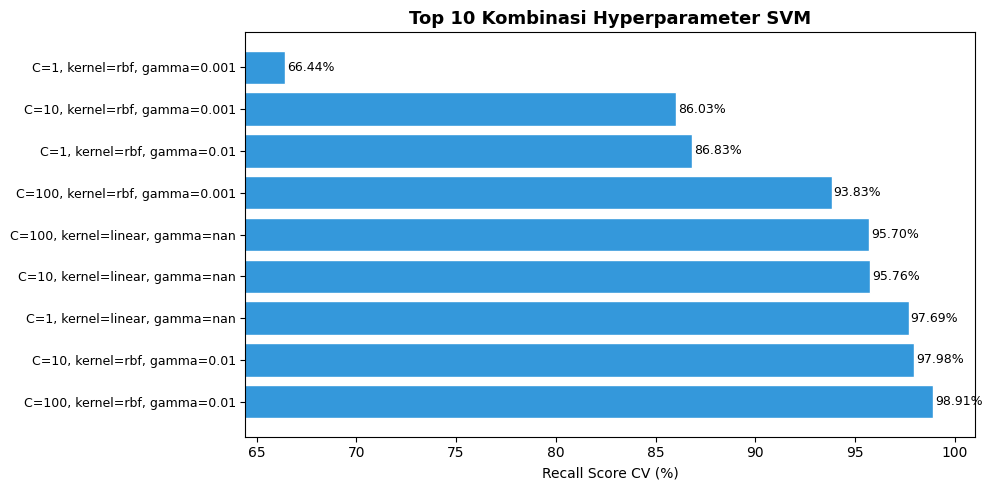

In [ ]:
# Visualisasi hasil Grid Search
results = pd.DataFrame(classifier.cv_results_)
results_sorted = results.sort_values('mean_test_score', ascending=False)

print("Top 5 kombinasi parameter:")
display(results_sorted[['param_C', 'param_kernel',
                          'mean_test_score', 'std_test_score']].head(5).round(4))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
top10 = results_sorted.head(10)
labels = [f"C={r['param_C']}, kernel={r['param_kernel']}, gamma={r.get('param_gamma', '-')}"
          for _, r in top10.iterrows()]
scores = top10['mean_test_score'].values * 100

bars = ax.barh(range(len(labels)), scores, color='#3498db', edgecolor='white')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Recall Score CV (%)')
ax.set_title('Top 10 Kombinasi Hyperparameter SVM', fontsize=13, fontweight='bold')
ax.set_xlim([min(scores)-2, 101])

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Evaluasi Model Final

In [ ]:
# Gunakan model terbaik hasil Grid Search
best_svm = classifier.best_estimator_
y_pred_best = best_svm.predict(X_test)

print("=" * 55)
print("EVALUASI FINAL — SVM SETELAH HYPERPARAMETER TUNING")
print("=" * 55)
print(f"Parameter terbaik : {classifier.best_params_}")
print()
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_best)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_best)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_test, y_pred_best)*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))


EVALUASI FINAL — SVM SETELAH HYPERPARAMETER TUNING
Parameter terbaik : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

Accuracy  : 97.58%
Precision : 90.13%
Recall    : 91.95%
F1-Score  : 91.03%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.90      0.92      0.91       149

    accuracy                           0.98      1115
   macro avg       0.94      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



# Confusion Matrix

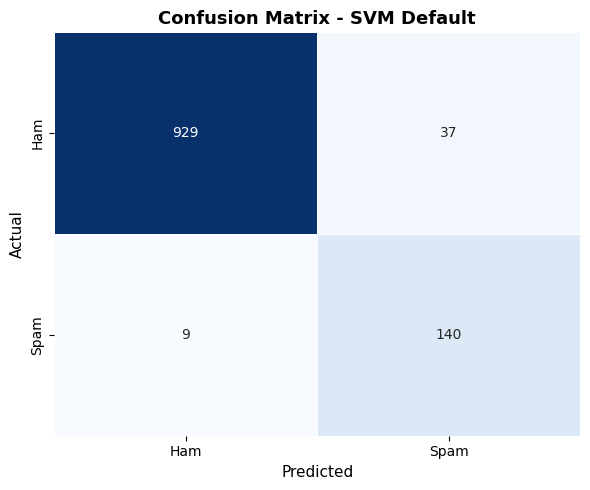

In [ ]:
# Confusion Matrix Default
cm_default = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            linewidths=0.5, cbar=False)
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title('Confusion Matrix - SVM Default', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_default.png', dpi=150, bbox_inches='tight')
plt.show()

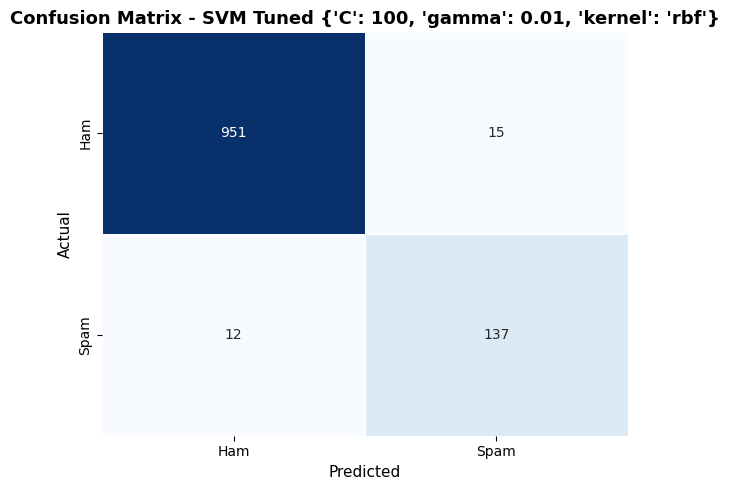

In [ ]:
# Confusion Matrix Tuned
cm_tuned = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            linewidths=0.5, cbar=False)
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'Confusion Matrix - SVM Tuned {classifier.best_params_}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

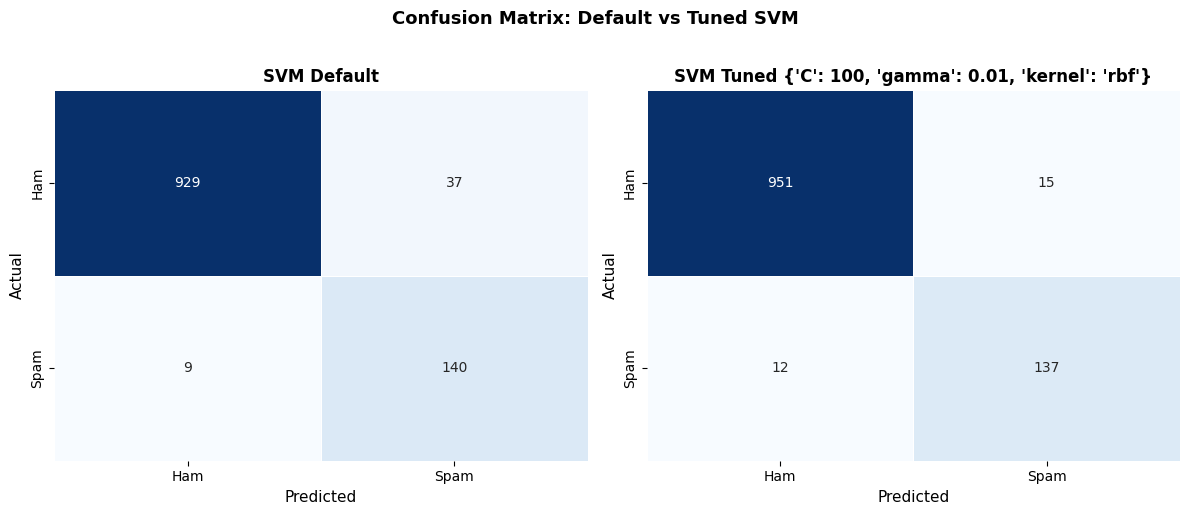

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                               [y_pred_default, y_pred_best],
                               ['SVM Default', f'SVM Tuned {classifier.best_params_}']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                linewidths=0.5, cbar=False)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix: Default vs Tuned SVM', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Perbandingan Metrik


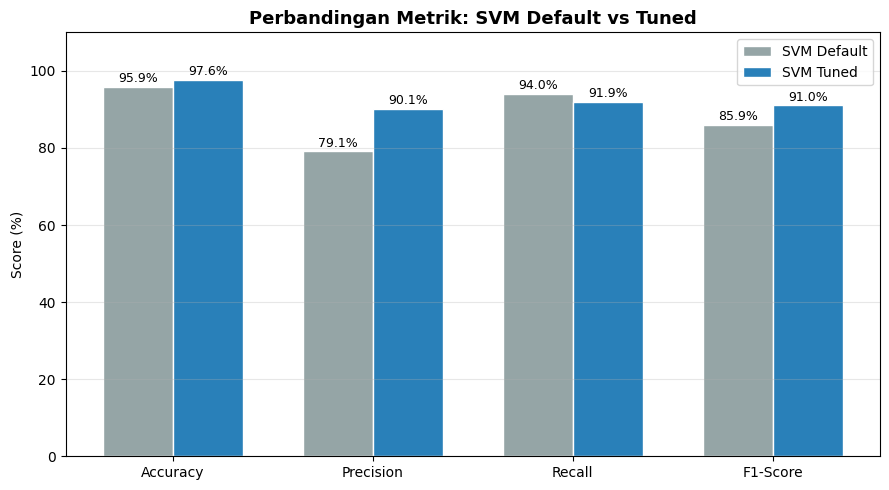

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
default_scores = [
    accuracy_score(y_test, y_pred_default),
    precision_score(y_test, y_pred_default),
    recall_score(y_test, y_pred_default),
    f1_score(y_test, y_pred_default)
]
tuned_scores = [
    accuracy_score(y_test, y_pred_best),
    precision_score(y_test, y_pred_best),
    recall_score(y_test, y_pred_best),
    f1_score(y_test, y_pred_best)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [s*100 for s in default_scores], width, label='SVM Default', color='#95a5a6', edgecolor='white')
bars2 = ax.bar(x + width/2, [s*100 for s in tuned_scores], width, label='SVM Tuned', color='#2980b9', edgecolor='white')

ax.set_ylabel('Score (%)')
ax.set_title('Perbandingan Metrik: SVM Default vs Tuned', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 110])  # mulai dari 0 biar semua bar kelihatan
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('perbandingan_metrik.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluasi Final

In [ ]:
best_svm = classifier.best_estimator_
y_pred_best = best_svm.predict(X_test)

print("=" * 55)
print("EVALUASI FINAL — SVM SETELAH HYPERPARAMETER TUNING")
print("=" * 55)
print(f"Parameter terbaik : {classifier.best_params_}")
print()
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_best)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_best)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_test, y_pred_best)*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

EVALUASI FINAL — SVM SETELAH HYPERPARAMETER TUNING
Parameter terbaik : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

Accuracy  : 97.58%
Precision : 90.13%
Recall    : 91.95%
F1-Score  : 91.03%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.90      0.92      0.91       149

    accuracy                           0.98      1115
   macro avg       0.94      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## 9. Prediksi Manual

In [ ]:
def predict_sms(text):
    """
    Prediksi apakah sebuah SMS adalah spam atau ham.
    """
    text_clean = preprocess_text(text)
    text_tfidf = tfidf.transform([text_clean])

    prediction = classifier.best_estimator_.predict(text_tfidf)[0]
    probability = classifier.best_estimator_.predict_proba(text_tfidf)[0]

    label = 'SPAM' if prediction == 1 else 'HAM'
    conf = probability[prediction] * 100

    print(f"SMS       : {text}")
    print(f"Hasil     : {label}")
    print(f"Confidence: {conf:.1f}%")
    print("-" * 55)

# Test beberapa contoh
print("=" * 55)
print("DEMO PREDIKSI SMS")
print("=" * 55 + "\n")

test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are you coming to the meeting tomorrow at 3pm?",
    "URGENT: Your account has been suspended. Call 08001234 immediately.",
    "Ok sounds good, see you tonight!",
    "FREE entry in 2 a wkly comp to win FA Cup final tkts. Text FA to 87121",
    "Can you pick up some groceries on your way home?"
]

for msg in test_messages:
    predict_sms(msg)

DEMO PREDIKSI SMS

SMS       : Congratulations! You've won a FREE iPhone. Click here to claim now!
Hasil     : SPAM
Confidence: 99.6%
-------------------------------------------------------
SMS       : Hey, are you coming to the meeting tomorrow at 3pm?
Hasil     : HAM
Confidence: 100.0%
-------------------------------------------------------
SMS       : URGENT: Your account has been suspended. Call 08001234 immediately.
Hasil     : SPAM
Confidence: 62.9%
-------------------------------------------------------
SMS       : Ok sounds good, see you tonight!
Hasil     : HAM
Confidence: 100.0%
-------------------------------------------------------
SMS       : FREE entry in 2 a wkly comp to win FA Cup final tkts. Text FA to 87121
Hasil     : SPAM
Confidence: 79.8%
-------------------------------------------------------
SMS       : Can you pick up some groceries on your way home?
Hasil     : HAM
Confidence: 100.0%
-------------------------------------------------------


## 10. Ringkasan Hasil

| Aspek | Detail |
|---|---|
| **Dataset** | SMS Spam Collection — 5.572 data |
| **Metode** | Support Vector Machine (SVM) |
| **Preprocessing** | Lowercase, remove URL/angka/punctuation, stopword removal, stemming |
| **Representasi Fitur** | TF-IDF (max 5000 fitur, unigram + bigram) |
| **Handling Imbalanced** | SMOTE pada data training |
| **Split Data** | 80% training, 20% testing |
| **Tuning** | Grid Search dengan 5-Fold Cross Validation |
| **Parameter Terbaik** | Lihat output Grid Search di atas |

### Catatan
- Model dievaluasi menggunakan **F1-Score** sebagai metrik utama karena data tidak seimbang
- SMOTE hanya diterapkan pada data **training** agar evaluasi tetap realistis
- Hasil akhir dapat dilihat pada confusion matrix dan classification report di atas
